In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, k as kB


# Physical constants
M_K39 = 39 * 1.6605e-27            # Mass of K39 in kg
A0 = 5.29177e-11                  # Bohr radius


# Dimensionless units
length_unit = 1e-6                                           # m
energy_unit = hbar**2 / (M_K39 * length_unit**2)             # J
time_unit   = hbar / energy_unit                             # s
temp_unit   = energy_unit / kB                               # K


# Simulation parameters 
L_phys     = 50e-6                # System size (m)
T_phys     = 100e-9               # Temperature (K)
n0_phys    = 20e12                # Density (m^-2)
omega_z    = 2 * np.pi * 1e3      # Trap frequency (Hz)
dt_phys    = 1e-6                 # Time step (s)
N_grid     = 256                  # Number of point
n_cut      = 2                    # Minimum occupation number (PGPE -> n_cut>>1)
save_every=100

# Initial state
a_ini   = 31 * A0                # Scattering length (m)
gamma_ini   = 0.01                # Bath coupling  
time_phys_thermalization  = 2 # Time evolutiom (s)                

# Final state
a_final               = a_ini/4   # Scattering length (m)
gamma_final           = 0         # Bath coupling  (PGPE -> 0)
time_phys_relaxation  =  0.5      # Time evolutiom (s)                


In [9]:
import json
from pathlib import Path
from dataclasses import dataclass


# Dimensionless & usefull quantities (DO NOT TOUCH)
L       = L_phys / length_unit
T       = np.round(T_phys / temp_unit, 4)
time    = time_phys_thermalization/time_unit
dt      = np.round(dt_phys/time_unit,5)
dx      = L / N_grid
n_steps = int(time/dt)
n0      = n0_phys * length_unit**2

osc_len_z  = np.sqrt(hbar / (M_K39 * omega_z))

g_phys_ini = (hbar**2 / M_K39) * np.sqrt(8 * np.pi) * (a_ini / osc_len_z)
g_ini    = np.round(g_phys_ini / (energy_unit * length_unit**2), 4)
print(g_ini)
g_phys_final  = (hbar**2 / M_K39) * np.sqrt(8 * np.pi) * (a_final / osc_len_z)
g_final    = np.round(g_phys_final / (energy_unit * length_unit**2), 4)

mu_ini   = np.round(g_ini * n0, 4)
mu_final = np.round(g_final * n0, 4)

x    = np.linspace(-L/2, L/2, N_grid, endpoint=False)
k    = np.fft.fftfreq(N_grid, d=dx) * 2 * np.pi
KX, KY = np.meshgrid(k, k)
K2   = KX**2 + KY**2

E_cut= np.max([mu_final,mu_ini]) + T * np.log(1+1/n_cut)
k_cut= np.sqrt(2*E_cut)
projector  = (np.sqrt(K2) <= k_cut).astype(complex)

T_BKT_ini= 2 * np.pi * n0 / (np.log(380 / g_ini))
T_BKT_final= 2 * np.pi * n0 / (np.log(380 / g_final))
lambda_db  = np.sqrt(2 * np.pi * hbar**2 / (M_K39 * T_phys * kB))
dk=2*np.pi/L
ek=dk**2/2
t_growth=1/(gamma_ini*max(mu_ini,T))

# Simulation stability

def check_stability(dx, dt, mu_ini, mu_final):
        HEADER   = '\033[95m'
        OKGREEN  = '\033[92m'
        WARNING  = '\033[93m'
        FAIL     = '\033[91m'
        ENDC     = '\033[0m'
        BOLD     = '\033[1m'

        def report_line(label, value, limit, passed):
            status = f"{OKGREEN}[PASS]{ENDC}" if passed else f"{FAIL}[FAIL]{ENDC}"
            print(f"{label:<35} {value:>10.4f} | {limit:>10.4f} | {status}")

        print(f"\n{BOLD}{HEADER}" + "="*75 + f"{ENDC}")
        print(f"{BOLD}SIMULATION DIAGNOSTIC REPORT{ENDC}")
        print(f"{HEADER}" + "="*75 + f"{ENDC}")
        print(f"{BOLD}{'Metric':<35} {'Value':>10} | {'Limit':>10} | {'Status':<10}{ENDC}")
        print("-" * 75)

        kin_val  = dt / (dx**2);  kin_lim = 0.2 / np.pi
        pass_kin = kin_val < kin_lim
        report_line("Kinetic Phase Propagator (dt/dx²)", kin_val, kin_lim, pass_kin)

        nl_val  = max(mu_ini,mu_final) * dt;  nl_lim = 0.1
        pass_nl = nl_val < nl_lim
        report_line("Mean-field Phase Rotation (μ·dt)", nl_val, nl_lim, pass_nl)

        xi       = 1 / np.sqrt(2 * max(mu_ini,mu_final))
        xi_res   = dx / xi;  xi_lim = 0.5
        pass_xi  = xi_res < xi_lim
        report_line("Grid Resolution (dx/ξ)", xi_res, xi_lim, pass_xi)

        print(f"{HEADER}" + "="*75 + f"{ENDC}")
        if not all([pass_kin, pass_nl, pass_xi]):
            print(f"{BOLD}{WARNING}RECOMMENDED SYSTEM TUNING:{ENDC}")
            if not pass_kin or not pass_nl:
                print("  * Temporal Accuracy: Reduce 'dt'.")
            if not pass_xi:
                print("  * Spatial Resolution: Increase 'N' or decrease 'L_grid'.")
            print(f"{HEADER}" + "="*75 + f"{ENDC}\n")
        else:
            print(f"{OKGREEN}{BOLD}System parameters are optimal.{ENDC}\n")

check_stability(dx, dt, mu_ini, mu_final)


# Parameter recap and PGPE cutoff check
@dataclass
class SimParams:
    name: str
    value: float
    unit: str = ""
    fmt: str = ".4f"

# Collect all data into a structured list
data = [
    SimParams("L", L),
    SimParams("T", T),
    SimParams("Time (thermal)", time_phys_thermalization/time_unit),
    SimParams("T_growth", t_growth),
    SimParams("dt", dt, fmt=".6f"),
    SimParams("n_steps", n_steps, fmt=".2e"),
    SimParams("n0", n0, fmt=".6f"),
    SimParams("mu_ini", mu_ini, fmt=".6f"),
    SimParams("mu_final", mu_final, fmt=".6f"),
    SimParams("E_cut", E_cut, fmt=".6f"),
    SimParams("k_cut", k_cut, fmt=".6f"),
    SimParams("T_BKT_final", T_BKT_final, fmt=".6f"),
    SimParams("T_BKT_ini", T_BKT_ini, fmt=".6f"),
]

# Print neatly
print(f"\n{'='*45}\n{'SIMULATION PARAMETER RECAP':^45}\n{'='*45}")
for p in data:
    print(f"{p.name:<20} : {p.value:>{p.fmt}} {p.unit}")

# Logic checks
print(f"\n{'='*45}\n{'CUTOFF VALIDATION':^45}\n{'='*45}")
print(f"Modes: {int(np.sum(projector != 0)):<8} / {N_grid**2}")
print(f"E_cut vs Max(mu): {'OK' if E_cut > max(mu_ini, mu_final) else 'WARNING'}")
print(f"k_cut vs k_max:   {'OK' if k_cut < np.sqrt(K2).max() else 'WARNING'}")



# Folder creation
base_dir = Path(r"D:\Users\Public\Documents\Louis\Simulations data\Data - relaxation")
folder_name = f"T={T:.2f}-mu_ini={mu_ini:.2f}-n0={n0:.2f}-gamma={gamma_ini:.4f}-dt={dt}"
full_path = base_dir / folder_name
full_path.mkdir(parents=True, exist_ok=True)

parameters = {
    "L_phys": L_phys,
    "T_phys": T_phys,
    "n0_phys": n0_phys,
    "omega_z": omega_z,
    "mu_ini": mu_ini,
    "L": L,
    "T": T,
    "gamma_ini": gamma_ini,
    "dt": dt,
    "n_steps": n_steps,
    "N_grid": N_grid,
    "k_cut": k_cut,
    "save_every":save_every
}


with open(full_path / "metadata_initial_state.json", "w") as f:
    json.dump(parameters, f, indent=4)

print(f"\n--- SAVING ---")
print(f"Metadata successfully saved to: '{full_path / 'metadata_initial_state.json'}'")




0.0162

SIMULATION DIAGNOSTIC REPORT
Metric                                   Value |      Limit | Status    
---------------------------------------------------------------------------
Kinetic Phase Propagator (dt/dx²)       0.0427 |     0.0637 | [PASS]
Mean-field Phase Rotation (μ·dt)        0.0005 |     0.1000 | [PASS]
Grid Resolution (dx/ξ)                  0.1572 |     0.5000 | [PASS]
System parameters are optimal.


         SIMULATION PARAMETER RECAP          
L                    : 50.0000 
T                    : 8.0396 
Time (thermal)       : 3256.8868 
T_growth             : 12.4384 
dt                   : 0.001630 
n_steps              : 2.00e+06 
n0                   : 20.000000 
mu_ini               : 0.324000 
mu_final             : 0.080000 
E_cut                : 3.583777 
k_cut                : 2.677229 
T_BKT_final          : 10.963858 
T_BKT_ini            : 12.487803 

              CUTOFF VALIDATION              
Modes: 1433     / 65536
E_cut vs Max(mu): OK
k_cut v

# Solver

In [10]:
def evolve_SPGPE(psi, g, mu, gamma):
    psi_k = np.fft.fft2(psi) * projector

    V = g * np.abs(psi)**2
    force = (-1j - gamma) * (V - mu) * psi

    noise = (np.random.normal(size=psi.shape)
                + 1j*np.random.normal(size=psi.shape)) / np.sqrt(2)

    noise_scale = np.sqrt(2 * gamma * T * dt / dx**2)
    dW = np.fft.fft2(noise_scale * noise) * projector

    drift = (-1j - gamma) * (0.5 * K2)
    psi_k = (psi_k + np.fft.fft2(force)*projector*dt + dW) / (1 - drift*dt)

    return np.fft.ifft2(psi_k * projector)

# Initial state thermalization

In [4]:
psi_storage = np.memmap(full_path/'psi_gound_state.dat',
                        dtype=np.complex128,
                        mode='r+',
                        shape=(n_steps//save_every+1,N_grid,N_grid))
psi0=psi_storage[-1]
del psi_storage

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Users\\Public\\Documents\\Louis\\Simulations data\\Data - relaxation\\T=11.26-mu_ini=1.29-n0=20.00-gamma=0.0300-dt=0.00163\\psi_gound_state.dat'

In [11]:
import tqdm


file=full_path/'psi_gound_state.dat'
# file.unlink()  #     Deletes the existing file

psi_storage = np.memmap(file,
                        dtype=np.complex128,
                        mode='w+',
                        shape=(n_steps//save_every+1,N_grid,N_grid))


psi= np.sqrt(n0)*np.ones((N_grid,N_grid), dtype=np.complex128)
psi*=np.exp(1j*2*np.pi*np.random.rand(N_grid,N_grid))
psi+=0.01*(np.random.rand(N_grid,N_grid)+1j*np.random.rand(N_grid,N_grid))

psi = (np.random.normal(size=(N_grid, N_grid)) + 
       1j * np.random.normal(size=(N_grid, N_grid))) * .1
# psi = (ifft2(fft2(psi) *  projector)) # Initial projection

# psi=psi0
j=0
for i in tqdm.tqdm(range(n_steps)):
    
    psi= evolve_SPGPE(psi, g_ini, mu_ini, gamma_ini)

    if i % save_every ==0:
        psi_storage[j,:,:] = psi

        if j%10 ==0:
            psi_storage.flush()

        j+=1

psi_storage.flush()



100%|██████████| 1998090/1998090 [10:00:25<00:00, 55.46it/s]  


In [12]:
# read ground state
# psi_storage = np.memmap(full_path/'psi_gound_state.dat',
#                         dtype=np.complex128,
#                         mode='r',
#                         shape=(n_steps//save_every+1,N_grid,N_grid))
p=r"D:\Users\Public\Documents\Louis\Simulations data\Data - relaxation\T=8.04-mu_ini=0.32-n0=20.00-gamma=0.0100-dt=0.00163\psi_gound_state.dat"

psi_storage = np.memmap(p,
                        dtype=np.complex128,
                        mode='r',
                        shape=(n_steps//save_every+1,N_grid,N_grid))

Ns=[]
for i in range(n_steps//save_every):
    psi_t= psi_storage[i]
    N=np.mean(np.abs(psi_t)**2)
    Ns.append(N)



17.930807082341843 20.0


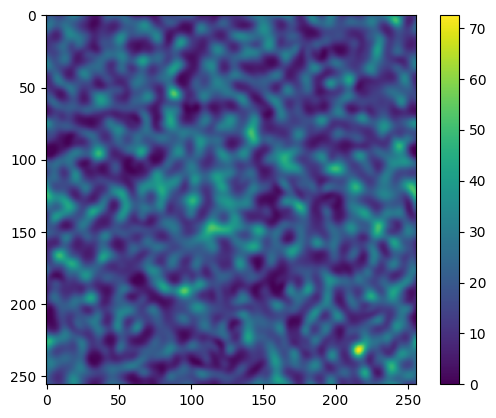

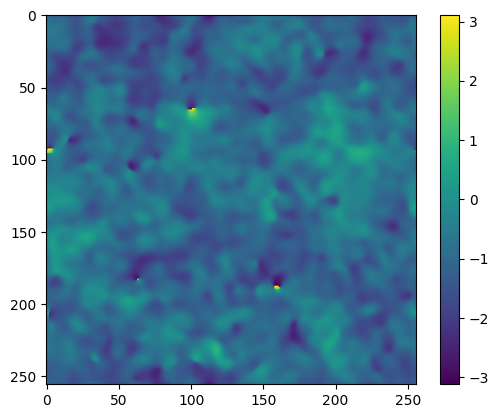

In [13]:
# psi_storage = np.memmap(full_path/'psi_gound_state.dat',
#                         dtype=np.complex128,
#                         mode='r',
#                         shape=(n_steps//save_every+1,N_grid,N_grid))

psi_storage = np.memmap(p,
                        dtype=np.complex128,
                        mode='r',
                        shape=(n_steps//save_every+1,N_grid,N_grid))
plt.figure()
plt.imshow(np.abs(psi_storage[-1])**2, vmin=0)
plt.colorbar()
plt.figure()
plt.imshow(np.angle(psi_storage[-1]))
plt.colorbar()

print(np.mean(np.abs(psi_storage[-1])**2),n0)

In [14]:
# psi_storage = np.memmap(full_path/'psi_gound_state.dat',
#                         dtype=np.complex128,
#                         mode='r',
#                         shape=(n_steps//save_every+1,N_grid,N_grid))

psi_storage = np.memmap(p,
                        dtype=np.complex128,
                        mode='r',
                        shape=(n_steps//save_every+1,N_grid,N_grid))


Psi_s=[]
for i in range(n_steps//save_every):
    psi_t= psi_storage[i]
    Psi_s.append(psi_t)


# Sanity checks

for "D:\Users\Public\Documents\Louis\Simulations data\Data - relaxation\T=8.04-mu_ini=0.32-n0=20.00-gamma=0.0300-dt=0.00163" we are at $T<T_{BKT}$. Thus, we expect a non zero condensate fraction, a algerbic decay of the first order correlation function and the density fluctuations should follow the bogoliubov theory. Obviously, the convergence of the number of particle and the condensate fraction are examined.

#### N convergence

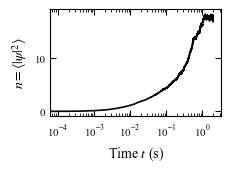

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",          
    "font.size": 10,                  
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.direction": "in",            
    "ytick.direction": "in",
    "xtick.top": True,                   
    "ytick.right": True,
    "xtick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.major.size": 4,
    "ytick.minor.size": 2,
    "axes.grid": False,                 
})

fig, ax = plt.subplots(figsize=(3.375/1.5, 2.5/1.5))

time_steps = np.arange(len(Ns)) * dt * time_unit * save_every
ax.plot(time_steps, Ns, linewidth=1.2, color='black', label='Particle Density')

ax.set_xlabel(r'Time $t$ (s)')
ax.set_ylabel(r'$n=\langle|\psi|^2\rangle$')
ax.set_xscale('log')

# ax.set_xlim(time_steps[0], time_steps[-1])


plt.tight_layout(pad=0.5)
# plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\N_convergence_thermal.pdf") 
# plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\N_convergence_thermal.png", dpi=300) 
plt.show()

### Condensate fraction

For the condesnate fraction, we will look at the evolution of the lowest level, i.e. $k=0$. First we analyse the average occupation number which should follow the bose distribution (at least for $k\neq0), we take care that $\mu \to 0 (means condensation).

In [16]:
import matplotlib.pyplot as plt
import numpy as np

psi_storage = np.memmap(full_path/'psi_gound_state.dat',
                        dtype=np.complex128,
                        mode='r',
                        shape=(n_steps//save_every+1,N_grid,N_grid))

condensate_fractions = []
for i in range(n_steps//save_every):
    psi_t = psi_storage[i]
    
    psi_k = np.fft.fft2(psi_t)
    
    k0_occupation = np.abs(psi_k[0, 0])**2
    
    N_total = np.sum(np.abs(psi_k)**2)
    
    condensate_fraction = k0_occupation / N_total
    condensate_fractions.append(condensate_fraction)

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern"],
#     "axes.labelsize": 12,
#     "font.size": 12,
#     "legend.fontsize": 10,
#     "xtick.labelsize": 10,
#     "ytick.labelsize": 10,
#     "figure.figsize": (3.4, 2.5), 
#     "lines.linewidth": 1.5
# })
plt.rcParams.update(plt.rcParamsDefault)


fig, ax = plt.subplots(constrained_layout=True, figsize=(3.4, 2.5))
time=np.arange(0,(n_steps//save_every)*dt,dt)
ax.plot(time,condensate_fractions, color='k', linestyle='-', label=r'$n_0 / N$')


ax.set_xlabel(r'Time ($t$)')
ax.set_ylabel(r'Condensate fraction $f_0$')
ax.grid(True, linestyle=':', alpha=0.6, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\condensate_fraction_evolution.pdf") 
# plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\condensate_fraction_evolution.png", dpi=300) 

plt.show()

KeyboardInterrupt: 

0.28229499851413764


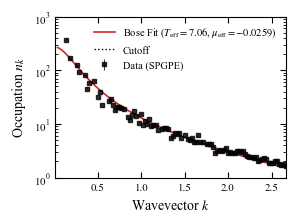

Effective temperature T=6.18, 7.06 | Input temperature T=8.04


In [19]:
from scipy.optimize import curve_fit

def plot_spectral_density_RJ_full_fit(psi_list, T_theory, mu_theory, L, N_grid, k_cut, dk, skip_bins=0):
    """
    Fits and plots the Occupation Number nk using the Rayleigh-Jeans distribution.
    Fits both T_eff and mu_eff.
    """
    dx = L / N_grid
    freqs = np.fft.fftfreq(N_grid, d=dx) * 2.0 * np.pi
    KX, KY = np.meshgrid(freqs, freqs)
    K_map = np.sqrt(KX**2 + KY**2)
    
    profiles = []
    k_bins = np.arange(0, k_cut , dk) 
    bin_centers = 0.5 * (k_bins[1:] + k_bins[:-1])
    
    for psi in psi_list:
        pk = np.abs(np.fft.fft2(psi))**2 * (dx**2 / N_grid**2)
        counts, _ = np.histogram(K_map, bins=k_bins, weights=pk)
        norms, _ = np.histogram(K_map, bins=k_bins)
        profiles.append(counts / np.where(norms > 0, norms, 1))
    
    nk_mean = np.mean(profiles, axis=0)
    nk_err = np.std(profiles, axis=0) / np.sqrt(max(len(psi_list), 1))
    n_avg=np.mean(np.abs(psi_list)**2)
    print(g_ini*n_avg)
    # --- Two-Parameter Rayleigh-Jeans Model ---
    def rj_model(k, T_eff,mu):
        Ek = k**2 / 2.0 

        return T_eff /(Ek-mu+1e-12)#

    
    def log_rj_model(k, T_eff, mu):
        return np.log(rj_model(k, T_eff, mu))

    def bose_model(k,T_eff,mu):
        Ek=k**2/2#np.sqrt(k**2/2*(k**2/2+2*g_ini*mu))# + g_ini*n_avg
        return 1/(np.exp((Ek-mu)/T_eff)-1)
    
    def log_bose_model(k,T,mu):
        return np.log(bose_model(k,T,mu))

    # --- Fitting ---
    mask = (nk_mean > 0)
    x_fit = bin_centers[mask][skip_bins:]
    y_log_fit = np.log(nk_mean[mask][skip_bins:])
    
    try:
        # Initial guess: [Theoretical T, 0]
        # Bounds: T must be positive, mu must be non-positive
        popt, _ = curve_fit(
            log_rj_model, x_fit, y_log_fit, 
            p0=[T_theory, mu_theory], 
            bounds=([1e-6, -np.inf], [np.inf, np.inf])
        )
        T_eff1, mu_eff1 = popt
    except Exception as e:
        print(f"RJ Fit failed: {e}")
        T_eff1, mu_eff1 = T_theory, mu_theory

    try:
        # Initial guess: [Theoretical T, 0]
        # Bounds: T must be positive, mu must be non-positive
        popt, _ = curve_fit(
            log_bose_model, x_fit, y_log_fit, 
            p0=[T_theory, mu_theory], 
            bounds=([1e-6, -np.inf], [np.inf, np.inf])
        )
        T_eff2, mu_eff2 = popt
    except Exception as e:
        print(f"Bose Fit failed: {e}")
        T_eff2, mu_eff2 = T_theory, mu_theory



    # Adjusted strictly to 1-column standard width
    fig, ax = plt.subplots(figsize=(3.375/1.2, 2.5/1.2))
    k_plot = np.linspace(bin_centers[skip_bins], k_cut, 400)

    # Plot Data: Square marker ('s') with thin errorbars and no caps to keep it clean
    ax.errorbar(bin_centers, nk_mean, yerr=nk_err, fmt='s', color='black', 
                markersize=3, elinewidth=0.7, capsize=0, alpha=0.8, label='Data (SPGPE)')

    # Plot Bose Fit: Thinner linewidth (1.2 to 1.5) works better for small print layouts
    ax.plot(k_plot, bose_model(k_plot, T_eff2, mu_eff2), color='tab:red', linewidth=1.2, 
            label=rf'Bose Fit ($T_{{\text{{eff}}}}={T_eff2:.2f}$, $\mu_{{\text{{eff}}}}={mu_eff2:.4f}$)')

    # Logarithmic scaling & explicit limits
    ax.set_yscale('log')
    ax.set_xlim(bin_centers[0], bin_centers[-1])
    ax.set_ylim(1e0, 1e3)

    # Axis labels using correct mathematical formatting
    ax.set_xlabel(r'Wavevector $k$')
    ax.set_ylabel(r'Occupation $n_k$')

    # Use axvline for proper infinite vertical lines, drawn behind data/fits using zorder
    ax.axvline(k_cut, color='black', linestyle=':', linewidth=1.0, label='Cutoff', zorder=1)    

    # Legend tuning: frameon=False and clean, smaller font size
    ax.legend(frameon=False, fontsize=7.5, loc='upper right')

    # Strict layout compression
    plt.tight_layout(pad=0.2)

    # Save configurations
    # Note: tight_layout handles margin issues, but bbox_inches='tight' guarantees zero accidental clipping
    # plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\occupation_number_thermal.pdf", bbox_inches='tight') 
    # plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\occupation_number_thermal.png", dpi=300, bbox_inches='tight') 
    plt.show()
    return T_eff1, mu_eff1,T_eff2, mu_eff2




# --- Execute ---
dk = 2*np.pi/N_grid
T_eff1, mu_eff1,T_eff2, mu_eff2 = plot_spectral_density_RJ_full_fit(Psi_s[-1000:], T, 0, L, N_grid, k_cut, dk, skip_bins=1)
print(f"Effective temperature T={T_eff1:.2f}, {T_eff2:.2f} | Input temperature T={T:.2f}")

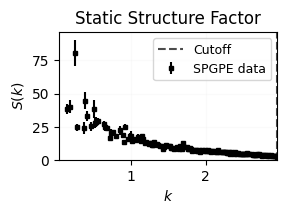

3.0095496221795144


In [30]:
from numpy.fft import fft2, fftshift, fftfreq
from scipy.optimize import curve_fit


def get_radially_averaged_sk(psi, dx, L, n_bins=100, k_max=None):
    """
    Computes the radially averaged static structure factor S(k) for a single
    snapshot. Average over snapshots OUTSIDE this function.

    Normalisation: S(k) = dx^2 / (n_avg * N^2) * |fft2(delta_n)|^2
    which satisfies S(k) -> 1 at large k (free particle limit).
    """
    N_grid = psi.shape[0]
    density = np.abs(psi)**2
    n_avg   = np.mean(density)
    delta_n = density - n_avg


    Sk_2d = fftshift(np.abs(fft2(delta_n))**2) * dx**2 / (n_avg * N_grid**2)
    
    k_1d  = fftshift(fftfreq(N_grid, d=dx) * 2 * np.pi)
    kx, ky = np.meshgrid(k_1d, k_1d)
    k_map = np.sqrt(kx**2 + ky**2)

    k_min  = 2 * np.pi / L
    k_max  = k_max if k_max is not None else np.max(k_1d)
    bins   = np.linspace(k_min, k_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    indices = np.digitize(k_map.ravel(), bins)
    sk_sum  = np.bincount(indices, weights=Sk_2d.ravel(), minlength=len(bins)+1)
    counts  = np.bincount(indices, minlength=len(bins)+1)

    mask   = counts[1:n_bins+1] > 0
    sk_1d  = sk_sum[1:n_bins+1][mask] / counts[1:n_bins+1][mask]
    return bin_centers[mask], sk_1d


def get_averaged_sk(psi_list, dx, L, n_bins=100, k_max=None):
    """
    Compute S(k) averaged over an ensemble of snapshots.
    Always compute S(k) per snapshot THEN average — never average psi first.
    """
    sk_list = []
    k_ref   = None
    for psi in psi_list:
        kk, sk = get_radially_averaged_sk(psi, dx, L, n_bins=n_bins, k_max=k_max)
        if k_ref is None:
            k_ref = kk
        sk_list.append(sk)
    return k_ref, np.mean(sk_list, axis=0), np.std(sk_list, axis=0) / np.sqrt(len(sk_list))




def bogoliubov_sk(k, g, n, T):
    """
    Classical-field static structure factor from Bogoliubov theory.
    """
    Ek      = k**2 / 2.0
    eps_k   = Ek+g*n#np.sqrt(Ek * (Ek + 2.0 * g * n))
    return Ek/eps_k/np.tanh(eps_k/(2*T))#2 * T * Ek / eps_k**2

def free(k, g, n, T):
    """
    Classical-field static structure factor from free theory.
    """
    Ek      = k**2 / 2.0 

    return 2 * T /(Ek-mu_ini)

def plot_sk(Psi_s, g, T_eff, dx, L, k_cut, dk, n_bins=150):
    k_c, sk_mean, sk_err = get_averaged_sk(
        Psi_s, dx, L, n_bins=n_bins, k_max=k_cut
    )

    n_actual = np.mean([np.mean(np.abs(p)**2) for p in Psi_s])

    k_theory = np.linspace(k_c[0], k_c[-1], 500)
    sk_th    = bogoliubov_sk(k_theory, g, n_actual, T_eff)
    sk_th_free = free(k_theory, g, n_actual, T_eff)

    fig, ax = plt.subplots(figsize=(3.375/1.2, 2.5/1.2))
    ax.errorbar(k_c, sk_mean, yerr=sk_err, fmt='s', color='black',
                markersize=3, label='SPGPE data')
    # ax.plot(k_theory, sk_th, 'r--', linewidth=2,
    #         label=rf'Bogoliubov: $T_{{eff}}$={T_eff:.2f}, $n$={n_actual:.2f}')

    # ax.plot(k_theory, sk_th_free, 'k--', linewidth=2,
    #        label=rf'Free: $T_{{eff}}$={T_eff:.2f}, $n$={n_actual:.2f}')

    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$S(k)$')
    ax.set_title('Static Structure Factor')
    ax.set_xlim(dk, k_cut)
    ax.set_ylim(0, np.max(sk_mean) * 1.2)
    ax.vlines(k_cut, 0, np.max(sk_mean)*1.2, color='black',
              linestyle='--', alpha=0.7, label='Cutoff')
    # ax.vlines(np.sqrt(2*g*n_actual), 0, np.max(sk_mean)*1.2, color='lightblue',
    #           linestyle='--', alpha=0.7, label=r'$k_\xi$')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.05)
    plt.tight_layout()
    plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\Sk_ini_thermal.pdf") 
    plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\Sk_ini_thermal.png", dpi=300) 
    plt.tight_layout(pad=0.5)

    plt.show()


plot_sk(Psi_s[-800::50], g_ini, 24.50, dx, L, k_cut, 2*np.pi/N_grid, n_bins=200)


N_t=np.sum(np.abs(Psi_s[-200:])**2, axis=(1,2))*dx**2
n_mean=np.mean(N_t)

n_var= np.mean((N_t-n_mean)**2)
print(n_var/n_mean)

Power Law: eta = 0.0756
Exponential: correlation length (xi) = 125.8263


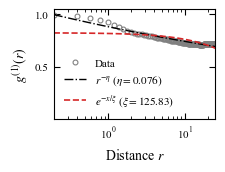

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def compute_g1(Psi_array):
    psi_k = np.fft.fft2(Psi_array, axes=(-2, -1))
    corr = np.fft.ifft2(np.abs(psi_k)**2, axes=(-2, -1))
    corr = np.fft.fftshift(corr, axes=(-2, -1))
    g1_sum = np.mean(corr.real, axis=0)
    g1_sum /= np.max(g1_sum)
    return g1_sum

g1_2d = compute_g1(np.array(Psi_s[-200:]))

center = N_grid // 2
g1_1d = g1_2d[center, center:]
x = np.linspace(0, L/2, N_grid // 2)

# 1. Define models
def power_law(x, A, eta):
    return A * x**(-eta)

def exponential(x, A, xi):
    return A * np.exp(-x / xi)

# 2. Prepare data for fitting (exclude x=0 to prevent divide-by-zero or log-scale issues)
fit_mask = x > 0
x_fit = x[fit_mask]
y_fit = g1_1d[fit_mask]

# 3. Fit Power Law
popt_pl, _ = curve_fit(power_law, x_fit, y_fit, p0=[0.9, 0.13])
A_pl, eta_pl = popt_pl

# 4. Fit Exponential
popt_exp, _ = curve_fit(exponential, x_fit, y_fit, p0=[1.0, L/4])
A_exp, xi_exp = popt_exp

print(f"Power Law: eta = {eta_pl:.4f}")
print(f"Exponential: correlation length (xi) = {xi_exp:.4f}")

# Single-column dimensions
fig, ax = plt.subplots(figsize=(3.375/1.5, 2.5/1.5))

# Plot experimental/simulated data
# Using a small filled circle with no face color (or alpha) often works beautifully in journals
ax.plot(x, g1_1d, 'o', label='Data', markersize=3.5, 
        markerfacecolor='none', markeredgecolor='gray', markeredgewidth=0.8)

# Plot fits with contrasting line styles (solid vs dashed) instead of only relying on colors
ax.plot(x_fit, power_law(x_fit, *popt_pl), '-.', 
        label=rf'$r^{{-\eta}}$ ($\eta={eta_pl:.3f}$)', color='black', linewidth=1)

ax.plot(x_fit, exponential(x_fit, *popt_exp), '--', 
        label=rf"$e^{{-x/\xi}}$ ($\xi={xi_exp:.2f}$)", color='tab:red', linewidth=1.2)

# Logarithmic scaling
ax.set_xscale('log')
# ax.set_yscale('log')

# IMPORTANT: Under log scale, xmin cannot be 0. We start at our first non-zero data point.
ax.set_xlim(x[1], L/2)
ax.set_ylim(1e-6,1.05)

# Axis labels
ax.set_xlabel(r"Distance $r$")
ax.set_ylabel(r"$g^{(1)}(r)$")

# Legend tuning: clear, compact, and borderless
# frameon=False is the standard PRL aesthetic
leg = ax.legend(frameon=False, fontsize=8, loc='best')

# Tighten the margins
plt.tight_layout(pad=0.5)
# plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\g1_sanity_check_thermal.pdf") 
# plt.savefig(r"C:\Users\BEC4-Share\Documents\Codes Louis\Relaxation_project\Pictures\Sanity check\g1_sanity_check_thermal.png", dpi=300) 
plt.show()

In [3]:
8.0396*temp_unit*1e9

99.9999986253646